# Assignment 2: Image and Filter Techniques
In this assignment, we explore Image and Filter techniques used in computational physics

## Package Imports / Global Variables
This will be the packages used

In [20]:
from pathlib import Path
import numpy as np
# import matplotlib as mpl
# mpl.use("qtagg") # Use Qt6 backend to display images
import matplotlib.pyplot as plt
from typing import * # organizing types for function inputting / debugging

In [4]:
IMG_DIR = Path('Images') #I just prefer using pathlib for directory management

MANDRILL = plt.imread(IMG_DIR / 'mandrill.png') # Find mandrill.png in the Images directory
EYE = plt.imread(IMG_DIR / 'eye.png')
PEPPERS = plt.imread(IMG_DIR / 'peppers.png')
print(type(MANDRILL))

<class 'numpy.ndarray'>


## Question 1

### Part a)

(10, 512, 4)


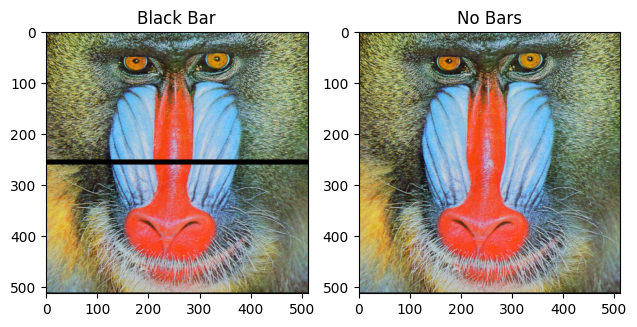

In [5]:
def black_line(img: np.ndarray, thickness: int = 10):
    """N-pixel wide lines across the entire image
    """
    if thickness > len(img):
        raise ValueError(f"Thickness of line must be less than image height: {thickness} > {img} is not allowed")
    if not isinstance(img, np.ndarray):
        raise TypeError("Must be an Array Object")
    
    image = img.copy()
    center = int(len(image)/2)
    half_width = int(thickness/2)
    
    upper = (center + half_width)
    lower = (center - half_width)
    image[lower:upper][:] = [0,0,0,1]

    print(image[lower:upper][:].shape)

    return image

#Main block, plotting
img = black_line(MANDRILL, 10)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Black Bar")
ax[1].imshow(MANDRILL)
ax[1].set_title("No Bars")
plt.tight_layout()
plt.show()



### Part b)

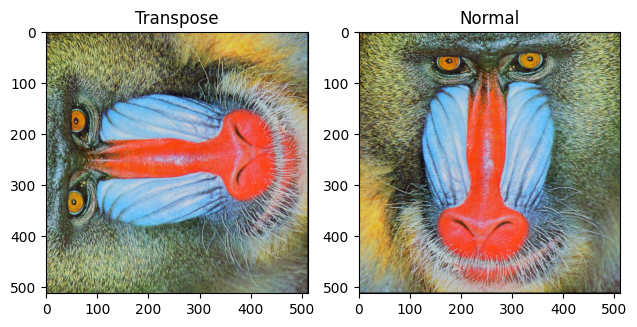

In [40]:
def transpose(img: np.ndarray):
    if not isinstance(img, np.ndarray):
        raise TypeError("Must be an Array Object")
    image = img.copy()
    row = len(image)
    col = len(image[0])

    transpose_image = [[[0,0,0,0] for _ in range(row)] for _ in range(col)]

    for i in range(row):
        for j in range(col):
            transpose_image[j][i] = image[i][j]
    return transpose_image

#Main block, plotting
img = transpose(MANDRILL)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Transpose")
ax[1].imshow(MANDRILL)
ax[1].set_title("Normal")
plt.tight_layout()
plt.show()    

### Part c)

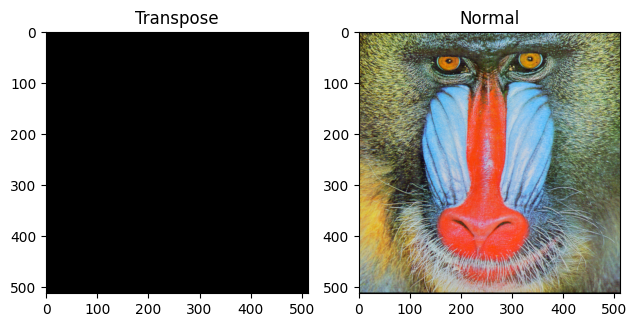

In [ ]:
def posterize(img: np.ndarray, value):

    if not isinstance(img, np.ndarray):
        raise TypeError("Must be an Array Object")
    if value > 255:
        raise ValueError("Must be less than 255")
    
    image = img.copy()
    divide = 255//value

    for i, rows in enumerate(img):
        for j, rgba in enumerate(rows):
            image[i][j][0] = (rgba[0]//divide)*divide
            image[i][j][1] = (rgba[1]//divide)*divide
            image[i][j][2] = (rgba[2]//divide)*divide

    return image

#Main block, plotting
img = posterize(MANDRILL,3)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[0].set_title("Transpose")
ax[1].imshow(MANDRILL)
ax[1].set_title("Normal")
plt.tight_layout()
plt.show()  